# Manual Trading round 2

You need to allocate this budget across three pillars:

- **Research**
- **Scale**
- **Speed**

You choose percentages for each pillar between 0–100%. Total allocation cannot exceed 100%. Your final PnL (Profit and Loss) score is:

PnL = (Research × Scale × Speed) − Budget_Used



**Research** determines how strong your trading edge is. It grows logarithmically from 0 (for 0 invested) to 200 000  (for 100 invested). The exact formula is:
``` research(r) = 200_000 * np.log(1 + x) / np.log(1 + 100) ```

**Scale** determines how broadly you deploy your strategy across markets. It grows linearly from 0 (for 0 invested) to 7 (for 100 invested).The exact formula is:
``` scale(s) = 7 * s / 100 ```

**Speed** determines how often you win the trades you target. It is **rank-based** across all players:

- Highest speed investment receives a `0.9` multiplier.
- Lowest receives `0.1`.
- Everyone in between is scaled linearly by rank, equal investments share the same rank.


In [ ]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

## Numerical maximisation of PnL

Full budget binds: $r+s+p=100$. Inner FOC gives $u(1+\ln u)=B+1$ with $u=1+r$, $B=100-p$, and then
$r^\star = u-1$, $s^\star = u\ln u$, gross $= K\,\mathcal{V}\,u(\ln u)^2$, PnL $= \text{gross}-50{,}000$.

Constante $K = 14{,}000/\ln 101 \approx 3033.507$, speed multiplier $\mathcal{V}\in[0.1,0.9]$.

In [24]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

K = 14_000.0 / np.log(101.0)        # ~3033.507
BUDGET_COST = 500.0                 # XIRECs per percentage point
FULL_BUDGET_USED = 100.0 * BUDGET_COST  # 50_000


def u_star(p: float) -> float:
    """Solve u*(1+ln u) = 101 - p on u >= 1 (unique root)."""
    B = 100.0 - p
    rhs = B + 1.0
    if rhs <= 1.0:                  # p = 100 -> u=1, r=0
        return 1.0
    f = lambda u: u * (1.0 + np.log(u)) - rhs
    return opt.brentq(f, 1.0, rhs + 1.0)


def allocation(p: float):
    """Return (r*, s*) given p, using the FOC."""
    u = u_star(p)
    r = u - 1.0
    s = u * np.log(u)               # = (100 - p) - r
    return r, s, u


def gross_pnl(p: float, V: float) -> float:
    u = u_star(p)
    return K * V * u * np.log(u) ** 2


def pnl(p: float, V: float) -> float:
    return gross_pnl(p, V) - FULL_BUDGET_USED


# sanity check: p=0 with V=0.9 should give ~618_103
r0, s0, u0 = allocation(0.0)
print(f"p=0: u*={u0:.4f}, r*={r0:.4f}, s*={s0:.4f}")
print(f"PnL(p=0, V=0.9) = {pnl(0.0, 0.9):,.2f}")
print(f"PnL(p=0, V=0.1) = {pnl(0.0, 0.1):,.2f}")

p=0: u*=24.1403, r*=23.1403, s*=76.8597
PnL(p=0, V=0.9) = 618,102.71
PnL(p=0, V=0.1) = 24,233.63


In [25]:
# Table of FOC solutions and optimal allocations over a grid of p
ps = [0, 5, 10, 15, 20, 30, 50, 80]
print(f"{'p':>4} {'B':>4} {'u*':>9} {'r*':>9} {'s*':>9} {'g(p)=u(ln u)^2':>16}")
for p in ps:
    r, s, u = allocation(p)
    g = u * np.log(u) ** 2
    print(f"{p:>4d} {100-p:>4d} {u:>9.4f} {r:>9.4f} {s:>9.4f} {g:>16.4f}")

   p    B        u*        r*        s*   g(p)=u(ln u)^2
   0  100   24.1403   23.1403   76.8597         244.7123
   5   95   23.1719   22.1719   72.8281         228.8944
  10   90   22.1957   21.1957   68.8043         213.2864
  15   85   21.2109   20.2109   64.7891         197.8993
  20   80   20.2170   19.2170   60.7830         182.7455
  30   70   18.1988   17.1988   52.8012         153.1951
  50   50   14.0115   13.0115   36.9885          97.6451
  80   20    7.0958    6.0958   13.9042          27.2453


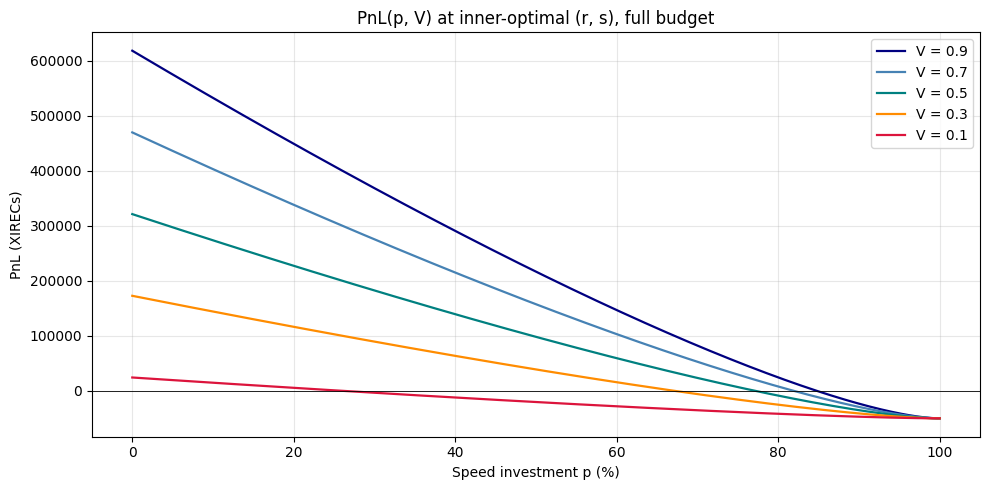

In [ ]:
# PnL(p) curves for fixed speed multipliers
p_grid = np.linspace(0.0, 100.0, 401)

fig, ax = plt.subplots(figsize=(10, 5))
for V, color in [(0.9, "navy"), (0.7, "steelblue"),
                 (0.5, "teal"), (0.3, "darkorange"), (0.1, "crimson")]:
    y = np.array([pnl(p, V) for p in p_grid])
    ax.plot(p_grid, y, color=color, lw=1.6, label=f"V = {V}")
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel("Speed investment p (%)")
ax.set_ylabel("PnL (XIRECs)")
ax.set_title("PnL(p, V) at inner-optimal (r, s), full budget")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# For a fixed V the envelope derivative -K V ln u(p) < 0, so the maximiser over p is p*=0.
# Confirm by 1-D numerical maximisation for each V on [0, 100].
print(f"{'V':>5} {'p*':>8} {'r*':>8} {'s*':>8} {'max PnL':>14}")
for V in [0.1, 0.3, 0.5, 0.7, 0.9]:
    res = opt.minimize_scalar(lambda p: -pnl(p, V), bounds=(0.0, 100.0), method="bounded",
                              options={"xatol": 1e-8})
    p_opt = res.x
    r, s, _ = allocation(p_opt)
    print(f"{V:>5.2f} {p_opt:>8.4f} {r:>8.4f} {s:>8.4f} {-res.fun:>14,.2f}")

    V       p*       r*       s*        max PnL
 0.10   0.0000  23.1403  76.8597      24,233.63
 0.30   0.0000  23.1403  76.8597     172,700.90
 0.50   0.0000  23.1403  76.8597     321,168.17
 0.70   0.0000  23.1403  76.8597     469,635.44
 0.90   0.0000  23.1403  76.8597     618,102.71


In [ ]:
# Candidate allocations table, integer rounding near FOC.
candidates = [(23, 77, 0), (21, 69, 10), (19, 61, 20), (17, 53, 30)]
Vs = [0.9, 0.7, 0.5, 0.3, 0.1]


def pnl_explicit(r: float, s: float, p: float, V: float) -> float:
    research = 200_000.0 * np.log(1.0 + r) / np.log(101.0)
    scale = 7.0 * s / 100.0
    return research * scale * V - BUDGET_COST * (r + s + p)


header = f"{'alloc (r,s,p)':>16} " + " ".join(f"V={V:<4}" for V in Vs)
print(header)
for r, s, p in candidates:
    row = f"{str((r, s, p)):>16} "
    row += " ".join(f"{pnl_explicit(r, s, p, V):>8,.0f}" for V in Vs)
    print(row)

   alloc (r,s,p) V=0.9  V=0.7  V=0.5  V=0.3  V=0.1 
     (23, 77, 0)  618,097  469,631  321,165  172,699   24,233
    (21, 69, 10)  532,293  402,895  273,496  144,098   14,699
    (19, 61, 20)  448,908  338,039  227,171  116,303    5,434
    (17, 53, 30)  368,232  275,291  182,351   89,411   -3,530
